Number of Nodes: 34
Number of Edges: 78


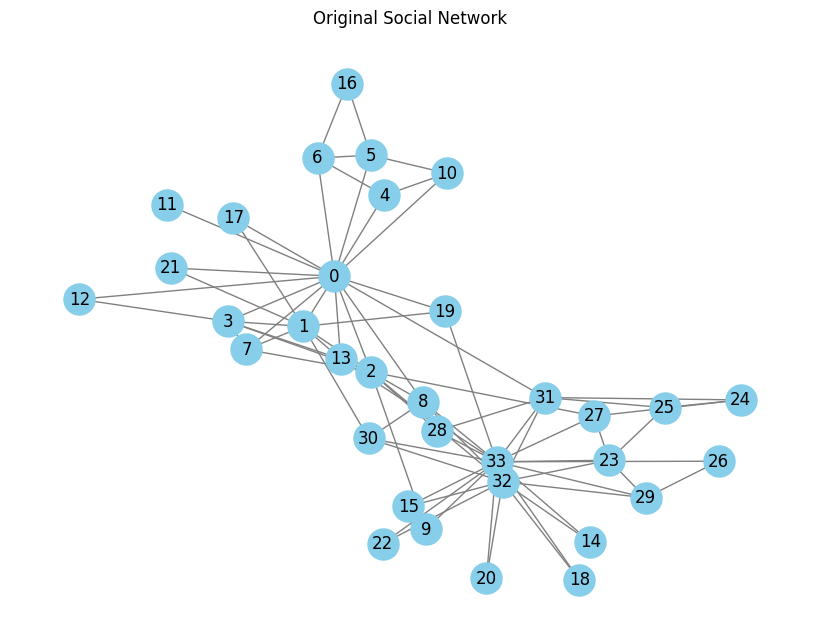


Detected Communities (2-way split):
Community 1: {0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21}
Community 2: {2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33}


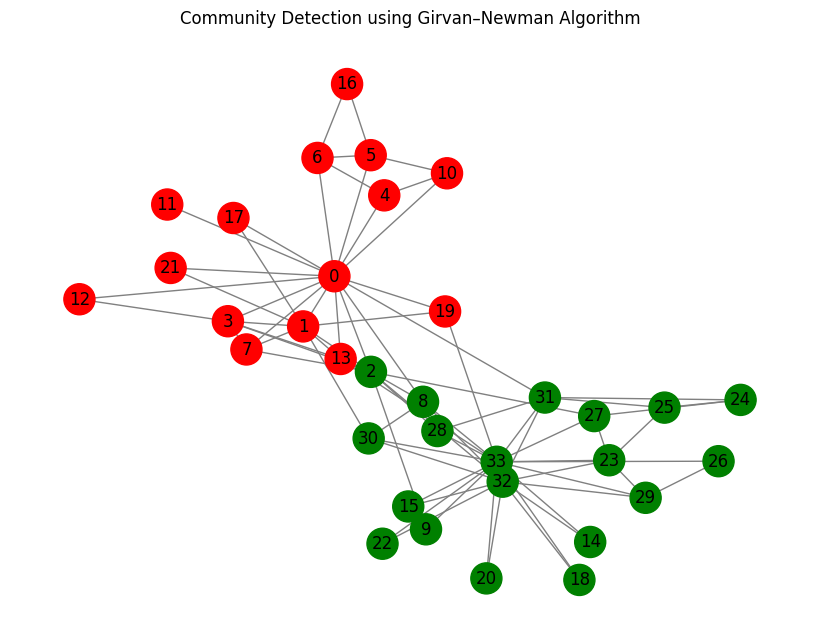


Hierarchical Community Structure:

Level 2 Communities:
Community 1: {0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21}
Community 2: {32, 33, 2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31}
Community 3: {9}

Level 3 Communities:
Community 1: {0, 1, 3, 7, 11, 12, 13, 17, 19, 21}
Community 2: {32, 33, 2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31}
Community 3: {4, 5, 6, 10, 16}
Community 4: {9}

Level 4 Communities:
Community 1: {0, 1, 3, 7, 11, 12, 13, 17, 19, 21}
Community 2: {2, 24, 25, 27, 28, 31}
Community 3: {4, 5, 6, 10, 16}
Community 4: {32, 33, 8, 14, 15, 18, 20, 22, 23, 26, 29, 30}
Community 5: {9}


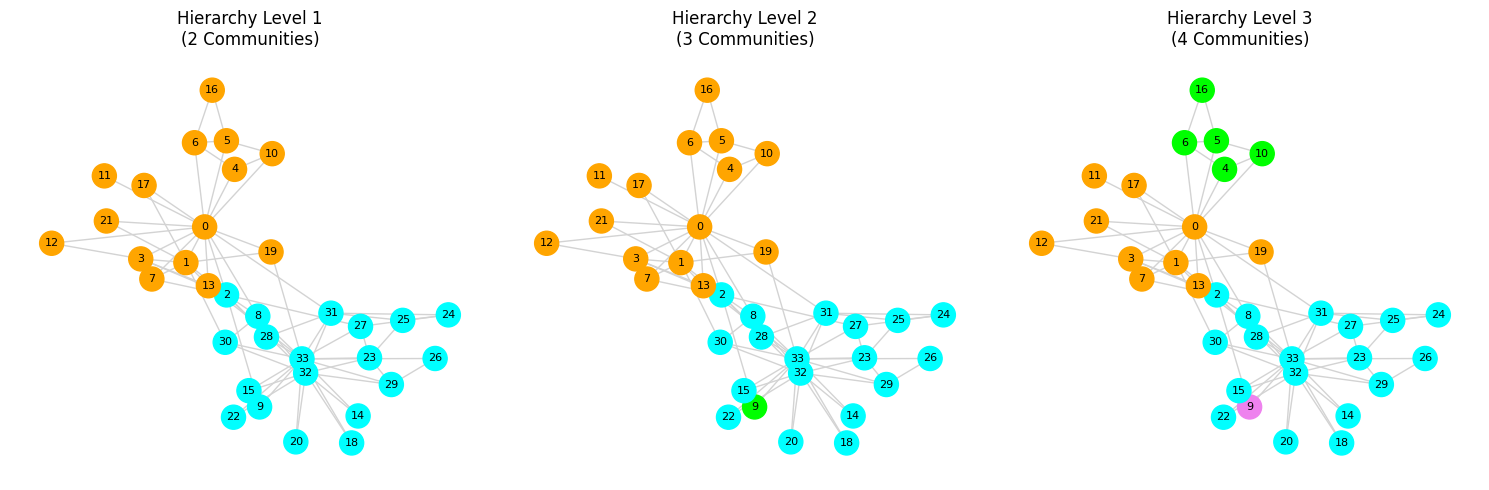

In [1]:
# =============================================================
# COMMUNITY DETECTION USING GIRVAN–NEWMAN ALGORITHM
# Real Dataset: Zachary Karate Club Social Network
# =============================================================

# ----------------------------
# IMPORT REQUIRED LIBRARIES
# ----------------------------
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import girvan_newman

# ----------------------------
# STEP 1: LOAD REAL DATASET
# ----------------------------
# Zachary Karate Club is a real-world social network dataset
# representing friendships among 34 club members.

G = nx.karate_club_graph()

print("Number of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())

# ----------------------------
# STEP 2: INITIAL NETWORK VISUALIZATION
# ----------------------------
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color="skyblue",
        edge_color="gray", node_size=500)
plt.title("Original Social Network")
plt.show()

# ----------------------------
# THEORY AND DEFINITIONS
# ----------------------------
"""
COMMUNITY:
-----------
A community is a group of nodes that are:
- Densely connected internally
- Sparsely connected externally

GIRVAN–NEWMAN ALGORITHM:
------------------------
It is a divisive hierarchical clustering algorithm.
It detects communities by iteratively removing edges with
the highest BETWENNESS CENTRALITY.

EDGE BETWENNESS CENTRALITY:
----------------------------
Measures the number of shortest paths that pass through an edge.

Formula:
---------
C_B(e) = Σ [ σ_st(e) / σ_st ]   for all s ≠ t

Where:
σ_st     = total number of shortest paths between nodes s and t
σ_st(e)  = number of those paths passing through edge e

ALGORITHM STEPS:
----------------
1. Compute edge betweenness centrality for all edges.
2. Remove the edge with highest betweenness.
3. Recompute betweenness for remaining edges.
4. Repeat until the network splits into communities.
"""

# ----------------------------
# STEP 3: APPLY GIRVAN-NEWMAN
# ----------------------------

# Generate community splits (hierarchical clustering)
communities_generator = girvan_newman(G)

# Extract first level partition (2 communities)
first_partition = next(communities_generator)

# Convert tuple of sets to list
communities = [set(c) for c in first_partition]

print("\nDetected Communities (2-way split):")
print("Community 1:", communities[0])
print("Community 2:", communities[1])

# ----------------------------
# STEP 4: COMMUNITY VISUALIZATION
# ----------------------------

color_map = []

for node in G:
    if node in communities[0]:
        color_map.append('red')
    else:
        color_map.append('green')

plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_color=color_map,
        edge_color="gray", node_size=500)
plt.title("Community Detection using Girvan–Newman Algorithm")
plt.show()

# ----------------------------
# STEP 5: MULTI-LEVEL COMMUNITY SPLITS
# ----------------------------

# Show hierarchical splits (dendrogram-style output)

print("\nHierarchical Community Structure:")

for i, community_level in enumerate(communities_generator, start=2):
    print(f"\nLevel {i} Communities:")
    for j, comm in enumerate(community_level, start=1):
        print(f"Community {j}: {comm}")
    if i == 4:   # Limit output for clarity
        break

# ----------------------------
# STEP 6: VISUALIZING HIERARCHICAL SPLITS
# ----------------------------

# Re-initialize the generator to start from the beginning
hierarchical_gen = girvan_newman(G)

# Plotting the first 3 levels of the hierarchy
plt.figure(figsize=(15, 5))

for i in range(3):
    level_communities = next(hierarchical_gen)

    # Create a color map for the current level
    node_colors = {}
    colors = ['orange', 'cyan', 'lime', 'violet', 'yellow']
    for idx, comm in enumerate(level_communities):
        for node in comm:
            node_colors[node] = colors[idx % len(colors)]

    # Map colors to nodes in order
    current_color_map = [node_colors[node] for node in G.nodes()]

    # Subplot for each split level
    plt.subplot(1, 3, i + 1)
    nx.draw(G, pos, with_labels=True, node_color=current_color_map,
            edge_color="lightgray", node_size=300, font_size=8)
    plt.title(f"Hierarchy Level {i+1}\n({len(level_communities)} Communities)")

plt.tight_layout()
plt.show()